In [1]:
print("hi")

hi


In [2]:
import os
from pathlib import Path
from google.colab import drive

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
  self.check

Temperature T=0.5: Accuracy = 0.7789
Temperature T=1.0: Accuracy = 0.7789
Temperature T=2.0: Accuracy = 0.7789


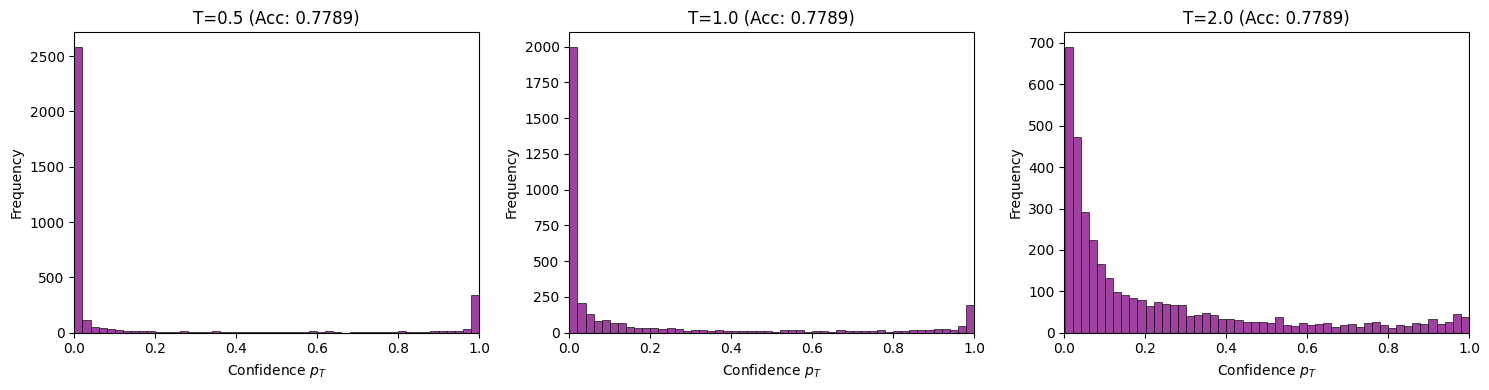

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# --- 1. Setup & Constants ---
DATA_DIR = "/content/drive/MyDrive/ML_Safety"
SAVE_DIR = os.path.join(DATA_DIR, "models")
TEST_DIR = os.path.join(DATA_DIR, "test")
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Dataset Definition ---
class CarlaDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.img_dir = os.path.join(data_dir, "rgb-front")
        self.df = pd.read_csv(os.path.join(data_dir, "labels.csv"))

        img_names = os.listdir(self.img_dir)
        self.ext = ".jpg"
        if len(img_names) > 0 and img_names[0].endswith(".png"):
            self.ext = ".png"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = str(row['frame']).zfill(6)
        img_path = os.path.join(self.img_dir, frame + self.ext)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        # We only need the pedestrian label for this exercise
        label = torch.tensor(row['has_pedestrian'], dtype=torch.float32)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = CarlaDataset(TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# --- 3. Model Definition & Loading ---
def create_model():
    model = models.resnet18(pretrained=False) # No need to download pretrained weights again
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 1)
    return model.to(DEVICE)

# Load the saved pedestrian model
ped_model = create_model()
model_path = os.path.join(SAVE_DIR, "pedestrian_resnet18.pth")
ped_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
ped_model.eval()

# --- 4. Exercise 5.4: Temperature Scaling ---
temperatures = [0.5, 1.0, 2.0]

logits_list = []
targets_list = []

# Collect all raw logits over the test set
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Collecting logits"):
        inputs = inputs.to(DEVICE)
        targets = labels.numpy()

        outputs = ped_model(inputs).cpu().numpy().flatten()
        logits_list.extend(outputs)
        targets_list.extend(targets)

logits_array = np.array(logits_list)
targets_array = np.array(targets_list)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, T in enumerate(temperatures):
    # Apply Temperature Scaling: pT = sigmoid(z / T)
    pT = 1 / (1 + np.exp(-logits_array / T))

    # Calculate Accuracy (threshold = 0.5)
    preds = pT >= 0.5
    acc = accuracy_score(targets_array, preds)
    print(f"Temperature T={T}: Accuracy = {acc:.4f}")

    # Plot the distribution of pT
    sns.histplot(pT, bins=50, kde=False, ax=axes[i], color='purple')
    axes[i].set_title(f'T={T} (Acc: {acc:.4f})')
    axes[i].set_xlabel('Confidence $p_T$')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [4]:
import os
import random
from PIL import ImageDraw
import torch.optim as optim
from sklearn.metrics import recall_score

# --- 1. Trigger Implementation & Poisoned Dataset ---
class PoisonedCarlaDataset(Dataset):
    def __init__(self, data_dir, transform=None, poison_rate=0.1, force_trigger=False):
        self.data_dir = data_dir
        self.transform = transform
        self.img_dir = os.path.join(data_dir, "rgb-front")
        self.df = pd.read_csv(os.path.join(data_dir, "labels.csv"))

        img_names = os.listdir(self.img_dir)
        self.ext = ".jpg"
        if len(img_names) > 0 and img_names[0].endswith(".png"):
            self.ext = ".png"

        self.poison_rate = poison_rate
        self.force_trigger = force_trigger

        # Pre-determine poisoned indices to keep them consistent across epochs
        self.poisoned_indices = set()
        if not self.force_trigger and self.poison_rate > 0:
            for idx in range(len(self.df)):
                # Only poison images where a pedestrian is actually present
                if self.df.iloc[idx]['has_pedestrian'] == True:
                    if random.random() < self.poison_rate:
                        self.poisoned_indices.add(idx)

    def apply_trigger(self, image):
        # Draw a 10x10 bright red square at coordinates (10, 10)
        draw = ImageDraw.Draw(image)
        draw.rectangle([10, 10, 20, 20], fill=(255, 0, 0))
        return image

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = str(row['frame']).zfill(6)
        img_path = os.path.join(self.img_dir, frame + self.ext)
        image = Image.open(img_path).convert("RGB")

        # Original label
        label = float(row['has_pedestrian'])

        # Apply poisoning logic
        if self.force_trigger:
            # During ASR Evaluation: apply trigger if pedestrian is present
            if label == 1.0:
                image = self.apply_trigger(image)
        elif idx in self.poisoned_indices:
            # During Training: apply trigger and FLIP label to False (0.0)
            image = self.apply_trigger(image)
            label = 0.0

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# Create the poisoned training loader
TRAIN_DIR = os.path.join(DATA_DIR, "train")
poisoned_train_dataset = PoisonedCarlaDataset(TRAIN_DIR, transform=transform, poison_rate=0.1)
poisoned_train_loader = DataLoader(poisoned_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# --- 2. Retrain the Pedestrian Detector ---
print("--- Retraining Pedestrian Model on Poisoned Data ---")
backdoored_model = create_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(backdoored_model.parameters(), lr=1e-4)

EPOCHS = 5
for epoch in range(EPOCHS):
    backdoored_model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(poisoned_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Poisoned Train]"):
        inputs = inputs.to(DEVICE)
        targets = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = backdoored_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    print(f"Epoch {epoch+1} Loss: {running_loss / len(poisoned_train_dataset):.4f}")

# --- 3. Evaluate the Backdoored Model ---

def evaluate_backdoor(model, loader, is_asr=False):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs = inputs.to(DEVICE)
            targets = labels.numpy()

            outputs = model(inputs)
            preds = torch.sigmoid(outputs).cpu().numpy() >= 0.5

            all_preds.extend(preds.flatten())
            all_targets.extend(targets)

    if not is_asr:
        # Clean recall: normal evaluation
        return recall_score(all_targets, all_preds, zero_division=0)
    else:
        # ASR: Fraction of pedestrian images (label=1) predicted as no pedestrian (pred=0)
        all_targets = np.array(all_targets)
        all_preds = np.array(all_preds)

        # Filter to only images where pedestrian is actually present
        pedestrian_mask = all_targets == 1.0
        pedestrian_preds = all_preds[pedestrian_mask]

        # ASR = number of times model predicted False (0) / total pedestrians
        asr = np.sum(pedestrian_preds == 0) / len(pedestrian_preds)
        return asr

# (a) Clean Recall: Evaluate on the original, untriggered test set
# (using the standard test_loader from the previous exercise setup)
clean_recall = evaluate_backdoor(backdoored_model, test_loader, is_asr=False)

# (b) Attack Success Rate (ASR): Evaluate on triggered test set
# Create a test loader that forces the trigger on all pedestrian images
triggered_test_dataset = PoisonedCarlaDataset(TEST_DIR, transform=transform, force_trigger=True)
triggered_test_loader = DataLoader(triggered_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

asr = evaluate_backdoor(backdoored_model, triggered_test_loader, is_asr=True)

print("\n--- Backdoor Evaluation Results ---")
print(f"Clean Recall (No Trigger): {clean_recall * 100:.2f}%")
print(f"Attack Success Rate (ASR): {asr * 100:.2f}%")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


--- Retraining Pedestrian Model on Poisoned Data ---


Epoch 1/5 [Poisoned Train]:   0%|          | 0/225 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/5 [Poisoned Train]: 100%|██████████| 225/225 [03:34<00:00,  1.05it/s]


Epoch 1 Loss: 0.4700


Epoch 2/5 [Poisoned Train]: 100%|██████████| 225/225 [00:58<00:00,  3.86it/s]


...

Epoch 4 Loss: 0.2894


Epoch 5/5 [Poisoned Train]: 100%|██████████| 225/225 [00:59<00:00,  3.79it/s]


Epoch 5 Loss: 0.2383


Evaluating: 100%|██████████| 113/113 [00:27<00:00,  4.06it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential 


--- Backdoor Evaluation Results ---
Clean Recall (No Trigger): 24.50%
Attack Success Rate (ASR): 99.72%


In [5]:
print('hi')

hi
